# Skill Analysis and NLP

## Job Market Skill Demand Analysis

**Project:** A Data-Driven Job Market Skill Demand Analysis and Career Recommendation System Using NLP and Machine Learning

This notebook analyzes the skills required across different career roles and prepares job description text for Natural Language Processing (NLP).

### Objectives

- Analyze the frequency of skills demanded in job postings.
- Identify the most important skills for different career roles.
- Examine relationships between careers and required skills.
- Process job description text using NLP techniques.
- Prepare text and skill features for the career recommendation system.

### 1. Import Libraries 

In [133]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully.")

Libraries imported successfully.


### 2. Load Processed Dataset

In [134]:
df = pd.read_csv("../data/job_postings_processed.csv")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (15000, 19)


In [135]:
df.head()

,job_id,title,company,location,remote_type,industry,company_size,experience_level,salary_min,salary_max,required_skills,education_required,description,posted_date,applications,days_to_fill,skill_count,salary_avg,year
0,JOB13473,Data Scientist,PolicyData Corp,"Pittsburgh, PA",onsite,government,startup,senior,138000,164000,Jupyter|Deep Learning|Python|Statistics|NLP|SQ...,bachelor,Join PolicyData Corp as a senior Data Scientis...,2023-01-01,26,61,7,151000.0,2023
1,JOB10866,Data Engineer,LearnEdge Systems,"Omaha, NE",remote,education,medium,mid,85000,103000,Python|PostgreSQL|BigQuery|Spark,bachelor,LearnEdge Systems is looking for a passionate ...,2023-01-01,75,55,4,94000.0,2023
2,JOB12905,Product Manager,Keystone Public Analytics,"Albuquerque, NM",hybrid,government,startup,entry,63000,77000,User Research|JIRA,bachelor,Join Keystone Public Analytics as a entry Prod...,2023-01-01,22,34,2,70000.0,2023
3,JOB01986,Research Scientist,Quantum Leap Digital,"Albuquerque, NM",onsite,tech,startup,entry,61000,71000,PyTorch|Statistics,bachelor,Quantum Leap Digital is looking for a passiona...,2023-01-01,18,37,2,66000.0,2023
4,JOB07952,Backend Engineer,Fabricate AI,"Albuquerque, NM",onsite,manufacturing,large,director,208000,245000,Python|PostgreSQL|Redis|Java|Docker|REST APIs|...,master,As a director Backend Engineer at Fabricate AI...,2023-01-01,131,114,9,226500.0,2023


### 3. Understanding the Required Skills Field



In [136]:
# Check for missing skill values

df['required_skills'].isna().sum()

np.int64(0)

In [137]:
# Display several skill combinations

df['required_skills'].head(10).tolist()

['Jupyter|Deep Learning|Python|Statistics|NLP|SQL|A/B Testing',
 'Python|PostgreSQL|BigQuery|Spark',
 'User Research|JIRA',
 'PyTorch|Statistics',
 'Python|PostgreSQL|Redis|Java|Docker|REST APIs|Go|gRPC|SQL',
 'Jenkins|CI/CD|Grafana|Terraform|AWS|Azure|Ansible|Kubernetes',
 'REST APIs|Python|Go|gRPC|Redis',
 'Experimentation|Deep Learning|Python|Statistics|TensorFlow|Machine Learning|Publication Record',
 'TypeScript|C++|Go|Docker|Kubernetes|Redis',
 'Kubernetes|Kafka|Java|AWS']

In [138]:
# Summary of skills required per job posting

df['skill_count'].describe()

count    15000.000000
mean         5.824533
std          1.997234
min          2.000000
25%          4.000000
50%          6.000000
75%          7.000000
max         10.000000
Name: skill_count, dtype: float64

In [139]:
skill_count_distribution = df['skill_count'].value_counts().sort_index()

skill_count_distribution

skill_count
2     1006
3     1040
4     2442
5     1434
6     3119
7     2428
8     2382
9      958
10     191
Name: count, dtype: int64

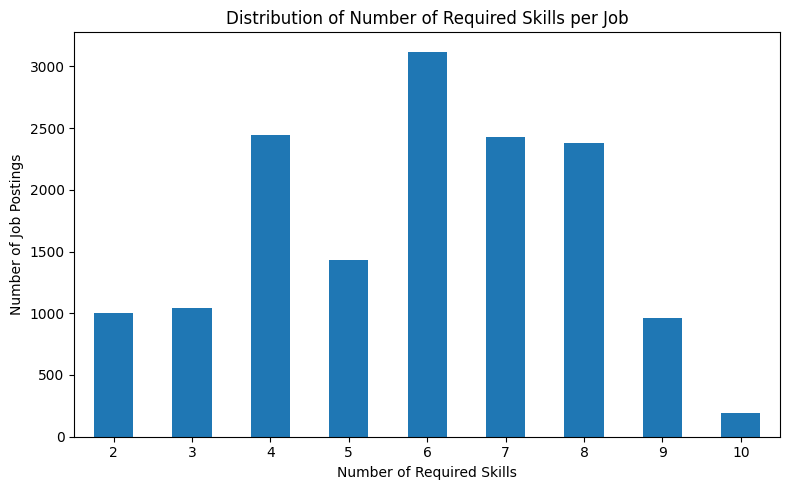

In [140]:
plt.figure(figsize=(8, 5))

skill_count_distribution.plot(kind='bar')

plt.title('Distribution of Number of Required Skills per Job')
plt.xlabel('Number of Required Skills')
plt.ylabel('Number of Job Postings')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### ## 4. Skill Extraction and Frequency Analysis

In [141]:
# Split required skills and create individual skill records

skills = (
    df['required_skills']
    .str.split('|')
    .explode()
    .str.strip()
)

skills.head(20)

0          Jupyter
0    Deep Learning
0           Python
0       Statistics
0              NLP
0              SQL
0      A/B Testing
1           Python
1       PostgreSQL
1         BigQuery
1            Spark
2    User Research
2             JIRA
3          PyTorch
3       Statistics
4           Python
4       PostgreSQL
4            Redis
4             Java
4           Docker
Name: required_skills, dtype: object

In [142]:
print("Total skill records:", len(skills))
print("Unique skills:", skills.nunique())

Total skill records: 87368
Unique skills: 69


In [143]:
# Count the frequency of each skill

skill_frequency = skills.value_counts()

skill_frequency.head(20)

required_skills
Python              5873
SQL                 4363
Docker              2675
Kubernetes          2673
AWS                 2672
Statistics          2454
A/B Testing         2432
TensorFlow          2330
PyTorch             2304
Spark               2064
PostgreSQL          1911
User Research       1893
Figma               1869
Machine Learning    1574
Deep Learning       1550
dbt                 1547
Tableau             1482
Airflow             1403
CI/CD               1394
Kafka               1388
Name: count, dtype: int64

In [144]:
# Create the skill demand dataframe

skill_demand = pd.DataFrame({
    'Skill': skill_frequency.index,
    'Job_Postings': skill_frequency.values
})

skill_demand['Demand_Percentage'] = (
    skill_demand['Job_Postings'] / len(df) * 100
).round(2)

skill_demand.head(20)

,Skill,Job_Postings,Demand_Percentage
0,Python,5873,39.15
1,SQL,4363,29.09
2,Docker,2675,17.83
3,Kubernetes,2673,17.82
4,AWS,2672,17.81
5,Statistics,2454,16.36
6,A/B Testing,2432,16.21
7,TensorFlow,2330,15.53
8,PyTorch,2304,15.36
9,Spark,2064,13.76


In [145]:
# Split required skills and create individual skill records

skills = (
    df['required_skills']
    .str.split('|')
    .explode()
    .str.strip()
)

print("Total skill records:", len(skills))
print("Unique skills:", skills.nunique())

Total skill records: 87368
Unique skills: 69


### 5. Top 20 Most In-Demand Skills

In [146]:
# Select the top 20 most demanded skills

top_20_skills = skill_demand.head(20)

top_20_skills

,Skill,Job_Postings,Demand_Percentage
0,Python,5873,39.15
1,SQL,4363,29.09
2,Docker,2675,17.83
3,Kubernetes,2673,17.82
4,AWS,2672,17.81
5,Statistics,2454,16.36
6,A/B Testing,2432,16.21
7,TensorFlow,2330,15.53
8,PyTorch,2304,15.36
9,Spark,2064,13.76


<Figure size 1000x700 with 0 Axes>

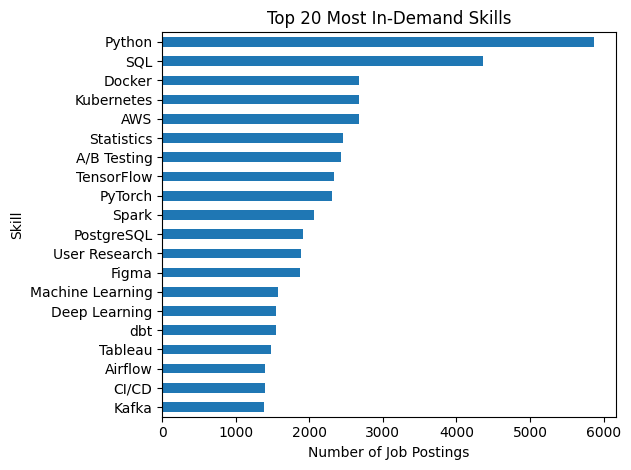

In [147]:
plt.figure(figsize=(10, 7))

top_20_skills.sort_values('Job_Postings').plot(
    x='Skill',
    y='Job_Postings',
    kind='barh',
    legend=False
)

plt.title('Top 20 Most In-Demand Skills')
plt.xlabel('Number of Job Postings')
plt.ylabel('Skill')

plt.tight_layout()
plt.show()

<Figure size 1000x700 with 0 Axes>

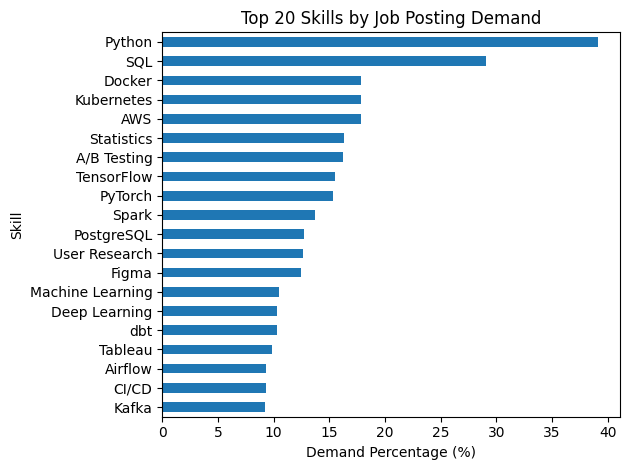

In [148]:
plt.figure(figsize=(10, 7))

top_20_skills.sort_values('Demand_Percentage').plot(
    x='Skill',
    y='Demand_Percentage',
    kind='barh',
    legend=False
)

plt.title('Top 20 Skills by Job Posting Demand')
plt.xlabel('Demand Percentage (%)')
plt.ylabel('Skill')

plt.tight_layout()
plt.show()

### 6. Career-wise Skill Demand Analysis

In [149]:
# Calculate skill demand for each career

career_skill_demand = (
    df[['title', 'required_skills']]
    .assign(
        Skill=df['required_skills'].str.split('|')
    )
    .explode('Skill')
)

career_skill_demand['Skill'] = (
    career_skill_demand['Skill']
    .str.strip()
)

career_skill_demand.head(20)

,title,required_skills,Skill
0,Data Scientist,Jupyter|Deep Learning|Python|Statistics|NLP|SQ...,Jupyter
0,Data Scientist,Jupyter|Deep Learning|Python|Statistics|NLP|SQ...,Deep Learning
0,Data Scientist,Jupyter|Deep Learning|Python|Statistics|NLP|SQ...,Python
0,Data Scientist,Jupyter|Deep Learning|Python|Statistics|NLP|SQ...,Statistics
0,Data Scientist,Jupyter|Deep Learning|Python|Statistics|NLP|SQ...,NLP
0,Data Scientist,Jupyter|Deep Learning|Python|Statistics|NLP|SQ...,SQL
0,Data Scientist,Jupyter|Deep Learning|Python|Statistics|NLP|SQ...,A/B Testing
1,Data Engineer,Python|PostgreSQL|BigQuery|Spark,Python
1,Data Engineer,Python|PostgreSQL|BigQuery|Spark,PostgreSQL
1,Data Engineer,Python|PostgreSQL|BigQuery|Spark,BigQuery


In [150]:
# Count how frequently each skill appears within each career

career_skill_counts = (
    career_skill_demand
    .groupby(['title', 'Skill'])
    .size()
    .reset_index(name='Job_Postings')
)

career_skill_counts.head(20)

,title,Skill,Job_Postings
0,Backend Engineer,AWS,710
1,Backend Engineer,Docker,687
2,Backend Engineer,Go,693
3,Backend Engineer,Java,733
4,Backend Engineer,Kafka,722
5,Backend Engineer,Kubernetes,687
6,Backend Engineer,PostgreSQL,706
7,Backend Engineer,Python,727
8,Backend Engineer,REST APIs,678
9,Backend Engineer,Redis,722


In [151]:
# Calculate percentage demand within each career

career_totals = (
    df['title']
    .value_counts()
    .rename('Total_Jobs')
    .reset_index()
)

career_totals.columns = ['title', 'Total_Jobs']

career_skill_counts = career_skill_counts.merge(
    career_totals,
    on='title',
    how='left'
)

career_skill_counts['Demand_Percentage'] = (
    career_skill_counts['Job_Postings'] /
    career_skill_counts['Total_Jobs'] * 100
).round(2)

career_skill_counts.head(20)

,title,Skill,Job_Postings,Total_Jobs,Demand_Percentage
0,Backend Engineer,AWS,710,1463,48.53
1,Backend Engineer,Docker,687,1463,46.96
2,Backend Engineer,Go,693,1463,47.37
3,Backend Engineer,Java,733,1463,50.10
4,Backend Engineer,Kafka,722,1463,49.35
5,Backend Engineer,Kubernetes,687,1463,46.96
6,Backend Engineer,PostgreSQL,706,1463,48.26
7,Backend Engineer,Python,727,1463,49.69
8,Backend Engineer,REST APIs,678,1463,46.34
9,Backend Engineer,Redis,722,1463,49.35


In [152]:
data_scientist_skills = (
    career_skill_counts[
        career_skill_counts['title'] == 'Data Scientist'
    ]
    .sort_values('Demand_Percentage', ascending=False)
)

data_scientist_skills.head(10)

,title,Skill,Job_Postings,Total_Jobs,Demand_Percentage
48,Data Scientist,scikit-learn,657,1484,44.27
39,Data Scientist,NLP,649,1484,43.73
43,Data Scientist,SQL,645,1484,43.46
35,Data Scientist,A/B Testing,642,1484,43.26
38,Data Scientist,Machine Learning,638,1484,42.99
42,Data Scientist,R,636,1484,42.86
44,Data Scientist,Spark,632,1484,42.59
45,Data Scientist,Statistics,625,1484,42.12
47,Data Scientist,TensorFlow,624,1484,42.05
36,Data Scientist,Deep Learning,617,1484,41.58


### 7. Top Skills by Career

In [153]:
# Get the top 5 skills for each career

top_skills_by_career = (
    career_skill_counts
    .sort_values(
        ['title', 'Demand_Percentage'],
        ascending=[True, False]
    )
    .groupby('title')
    .head(5)
)

top_skills_by_career

,title,Skill,Job_Postings,Total_Jobs,Demand_Percentage
3,Backend Engineer,Java,733,1463,50.10
11,Backend Engineer,gRPC,728,1463,49.76
7,Backend Engineer,Python,727,1463,49.69
4,Backend Engineer,Kafka,722,1463,49.35
9,Backend Engineer,Redis,722,1463,49.35
12,Data Analyst,A/B Testing,897,1520,59.01
19,Data Analyst,Statistics,894,1520,58.82
20,Data Analyst,Tableau,890,1520,58.55
13,Data Analyst,Excel,887,1520,58.36
21,Data Analyst,dbt,884,1520,58.16


In [154]:
# Display career-wise top 5 skills

career_top5 = top_skills_by_career[
    ['title', 'Skill', 'Job_Postings', 'Demand_Percentage']
].reset_index(drop=True)

career_top5

,title,Skill,Job_Postings,Demand_Percentage
0,Backend Engineer,Java,733,50.10
1,Backend Engineer,gRPC,728,49.76
2,Backend Engineer,Python,727,49.69
3,Backend Engineer,Kafka,722,49.35
4,Backend Engineer,Redis,722,49.35
5,Data Analyst,A/B Testing,897,59.01
6,Data Analyst,Statistics,894,58.82
7,Data Analyst,Tableau,890,58.55
8,Data Analyst,Excel,887,58.36
9,Data Analyst,dbt,884,58.16


In [155]:
career_top5.to_csv(
    "../data/career_top5_skills.csv",
    index=False
)

print("Career top-5 skills dataset saved successfully.")

Career top-5 skills dataset saved successfully.


### 8. Career-Skill Demand Matrix

In [156]:
# Create Career × Skill demand matrix

career_skill_matrix = career_skill_counts.pivot_table(
    index='title',
    columns='Skill',
    values='Demand_Percentage',
    fill_value=0
)

career_skill_matrix

Skill,A/B Testing,AWS,AWS SageMaker,Adobe XD,Agile,Airflow,Ansible,Azure,BigQuery,C++,...,Tableau,TensorFlow,Terraform,TypeScript,Usability Testing,User Research,Wireframing,dbt,gRPC,scikit-learn
title,,,,,,,,,,,,,,,,,,,,,
Backend Engineer,0.00,48.53,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,49.76,0.00
Data Analyst,59.01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,58.55,0.00,0.00,0.00,0.00,0.00,0.00,58.16,0.00,0.00
Data Engineer,0.00,45.32,0.00,0.00,0.00,44.85,0.00,42.85,44.79,0.00,...,0.00,0.00,42.71,0.00,0.00,0.00,0.00,44.32,0.00,0.00
Data Scientist,43.26,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,39.89,42.05,0.00,0.00,0.00,0.00,0.00,0.00,0.00,44.27
DevOps Engineer,0.00,47.59,0.00,0.00,0.00,0.00,46.07,42.98,0.00,0.00,...,0.00,0.00,44.01,0.00,0.00,0.00,0.00,0.00,0.00,0.00
ML Engineer,0.00,0.00,50.59,0.00,0.00,48.35,0.00,0.00,0.00,0.00,...,0.00,50.07,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Product Manager,58.75,0.00,0.00,0.00,59.01,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,59.08,0.00,0.00,0.00,0.00
Research Scientist,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,65.42,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Software Engineer,0.00,38.21,0.00,0.00,0.00,0.00,0.00,0.00,0.00,37.76,...,0.00,0.00,0.00,39.24,0.00,0.00,0.00,0.00,0.00,0.00


In [157]:
print("Matrix shape:", career_skill_matrix.shape)
print("Number of careers:", career_skill_matrix.shape[0])
print("Number of skills:", career_skill_matrix.shape[1])

Matrix shape: (10, 69)
Number of careers: 10
Number of skills: 69


In [158]:
career_skill_matrix.to_csv(
    "../data/career_skill_matrix.csv"
)

print("Career-skill matrix saved successfully.")

Career-skill matrix saved successfully.


In [159]:
top_skill_names = skill_demand.head(20)['Skill']

career_skill_matrix[top_skill_names]

Skill,Python,SQL,Docker,Kubernetes,AWS,Statistics,A/B Testing,TensorFlow,PyTorch,Spark,PostgreSQL,User Research,Figma,Machine Learning,Deep Learning,dbt,Tableau,Airflow,CI/CD,Kafka
title,,,,,,,,,,,,,,,,,,,,
Backend Engineer,49.69,49.08,46.96,46.96,48.53,0.00,0.00,0.00,0.00,0.00,48.26,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,49.35
Data Analyst,57.70,57.63,0.00,0.00,0.00,58.82,59.01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,58.16,58.55,0.00,0.00,0.00
Data Engineer,43.78,44.32,0.00,0.00,45.32,0.00,0.00,0.00,0.00,44.79,43.25,0.00,0.00,0.00,0.00,44.32,0.00,44.85,0.00,44.52
Data Scientist,40.77,43.46,0.00,0.00,0.00,42.12,43.26,42.05,40.70,42.59,0.00,0.00,0.00,42.99,41.58,0.00,39.89,0.00,0.00,0.00
DevOps Engineer,45.59,0.00,45.11,42.91,47.59,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,45.25,0.00
ML Engineer,49.08,0.00,48.41,49.60,0.00,0.00,0.00,50.07,48.41,50.33,0.00,0.00,0.00,0.00,0.00,0.00,0.00,48.35,48.68,0.00
Product Manager,0.00,57.89,0.00,0.00,0.00,0.00,58.75,0.00,0.00,0.00,0.00,59.08,59.74,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Research Scientist,66.46,0.00,0.00,0.00,0.00,64.53,0.00,65.42,66.74,0.00,0.00,0.00,0.00,64.60,64.39,0.00,0.00,0.00,0.00,0.00
Software Engineer,41.30,37.44,38.66,39.43,38.21,0.00,0.00,0.00,0.00,0.00,35.95,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


### 9. Skill Co-occurrence Analysis

In [160]:
# Create a binary skill matrix for each job posting

skill_matrix = (
    df['required_skills']
    .str.get_dummies(sep='|')
)

skill_matrix.head()

,A/B Testing,AWS,AWS SageMaker,Adobe XD,Agile,Airflow,Ansible,Azure,BigQuery,C++,...,Tableau,TensorFlow,Terraform,TypeScript,Usability Testing,User Research,Wireframing,dbt,gRPC,scikit-learn
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


In [161]:
# Calculate how often skills occur together

skill_cooccurrence = skill_matrix.T.dot(skill_matrix)

skill_cooccurrence.head()

,A/B Testing,AWS,AWS SageMaker,Adobe XD,Agile,Airflow,Ansible,Azure,BigQuery,C++,...,Tableau,TensorFlow,Terraform,TypeScript,Usability Testing,User Research,Wireframing,dbt,gRPC,scikit-learn
A/B Testing,2432,0,0,0,556,0,0,0,0,0,...,801,265,0,0,0,555,0,541,0,289
AWS,0,2672,0,0,0,304,310,614,296,239,...,0,0,603,244,0,0,0,299,359,0
AWS SageMaker,0,0,766,0,0,380,0,0,0,0,...,0,383,0,0,0,0,0,0,0,0
Adobe XD,0,0,0,959,0,0,0,0,0,0,...,0,0,0,0,661,662,640,0,0,0
Agile,556,0,0,0,897,0,0,0,0,0,...,0,0,0,0,0,562,0,0,0,0


In [162]:
# Remove self-co-occurrences

cooccurrence_no_self = skill_cooccurrence.copy()

np.fill_diagonal(
    cooccurrence_no_self.values,
    0
)

cooccurrence_no_self.head()

,A/B Testing,AWS,AWS SageMaker,Adobe XD,Agile,Airflow,Ansible,Azure,BigQuery,C++,...,Tableau,TensorFlow,Terraform,TypeScript,Usability Testing,User Research,Wireframing,dbt,gRPC,scikit-learn
A/B Testing,0,0,0,0,556,0,0,0,0,0,...,801,265,0,0,0,555,0,541,0,289
AWS,0,0,0,0,0,304,310,614,296,239,...,0,0,603,244,0,0,0,299,359,0
AWS SageMaker,0,0,0,0,0,380,0,0,0,0,...,0,383,0,0,0,0,0,0,0,0
Adobe XD,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,661,662,640,0,0,0
Agile,556,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,562,0,0,0,0


In [163]:
# Convert the matrix into skill pairs

skill_pairs = (
    cooccurrence_no_self
    .stack()
    .reset_index()
)

skill_pairs.columns = [
    'Skill_1',
    'Skill_2',
    'Cooccurrence'
]

# Keep each pair only once
skill_pairs = skill_pairs[
    skill_pairs['Skill_1'] < skill_pairs['Skill_2']
]

skill_pairs = (
    skill_pairs
    .sort_values('Cooccurrence', ascending=False)
    .reset_index(drop=True)
)

skill_pairs.head(20)

,Skill_1,Skill_2,Cooccurrence
0,Python,SQL,1709
1,Python,Statistics,1474
2,A/B Testing,SQL,1367
3,Kubernetes,Python,1322
4,Python,TensorFlow,1319
5,PyTorch,TensorFlow,1293
6,Docker,Python,1290
7,PyTorch,Python,1281
8,Docker,Kubernetes,1233
9,Figma,User Research,1228


In [164]:
skill_pairs.head(20)

,Skill_1,Skill_2,Cooccurrence
0,Python,SQL,1709
1,Python,Statistics,1474
2,A/B Testing,SQL,1367
3,Kubernetes,Python,1322
4,Python,TensorFlow,1319
5,PyTorch,TensorFlow,1293
6,Docker,Python,1290
7,PyTorch,Python,1281
8,Docker,Kubernetes,1233
9,Figma,User Research,1228


### 10. Top Skill Combinations

In [165]:
# Select the top 15 skill combinations

top_skill_pairs = skill_pairs.head(15).copy()

top_skill_pairs['Skill_Pair'] = (
    top_skill_pairs['Skill_1'] +
    ' + ' +
    top_skill_pairs['Skill_2']
)

top_skill_pairs

,Skill_1,Skill_2,Cooccurrence,Skill_Pair
0,Python,SQL,1709,Python + SQL
1,Python,Statistics,1474,Python + Statistics
2,A/B Testing,SQL,1367,A/B Testing + SQL
3,Kubernetes,Python,1322,Kubernetes + Python
4,Python,TensorFlow,1319,Python + TensorFlow
5,PyTorch,TensorFlow,1293,PyTorch + TensorFlow
6,Docker,Python,1290,Docker + Python
7,PyTorch,Python,1281,PyTorch + Python
8,Docker,Kubernetes,1233,Docker + Kubernetes
9,Figma,User Research,1228,Figma + User Research


<Figure size 1000x700 with 0 Axes>

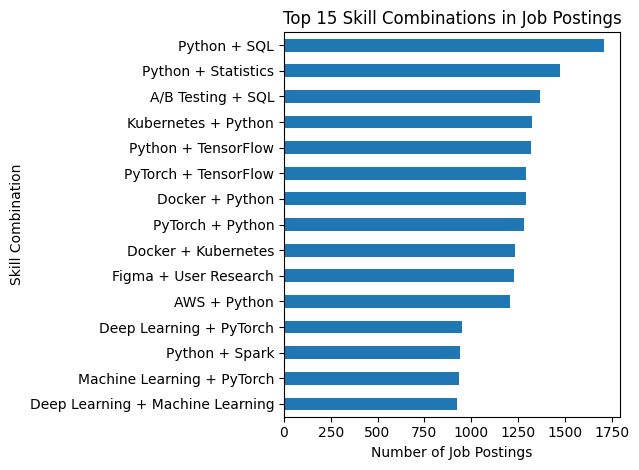

In [166]:
plt.figure(figsize=(10, 7))

top_skill_pairs.sort_values('Cooccurrence').plot(
    x='Skill_Pair',
    y='Cooccurrence',
    kind='barh',
    legend=False
)

plt.title('Top 15 Skill Combinations in Job Postings')
plt.xlabel('Number of Job Postings')
plt.ylabel('Skill Combination')

plt.tight_layout()
plt.show()

In [167]:
top_skill_pairs[
    ['Skill_1', 'Skill_2', 'Cooccurrence']
].to_csv(
    "../data/top_skill_pairs.csv",
    index=False
)

print("Top skill pairs saved successfully.")

Top skill pairs saved successfully.


### 11. NLP Text Preprocessing

In [168]:
# Inspect job description examples

df['description'].head(5)

0    Join PolicyData Corp as a senior Data Scientis...
1    LearnEdge Systems is looking for a passionate ...
2    Join Keystone Public Analytics as a entry Prod...
3    Quantum Leap Digital is looking for a passiona...
4    As a director Backend Engineer at Fabricate AI...
Name: description, dtype: object

In [169]:
# Calculate description length

df['description_length'] = df['description'].str.len()

df['description_length'].describe()

count    15000.000000
mean       273.401933
std         40.382452
min        191.000000
25%        239.000000
50%        265.000000
75%        306.000000
max        394.000000
Name: description_length, dtype: float64

In [170]:
# Check for missing descriptions

df['description'].isna().sum()

np.int64(0)

In [171]:
# Display one complete job description

print(df.loc[0, 'description'])

Join PolicyData Corp as a senior Data Scientist and help us build product analytics infrastructure using Jupyter, Deep Learning, and Python. We value technical excellence and foster an inclusive environment where everyone can thrive.


### 12. Text Cleaning

In [172]:
import re
import string

In [173]:
def clean_text(text):
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

In [174]:
df['clean_description'] = df['description'].apply(clean_text)

In [175]:
comparison = df[
    ['description', 'clean_description']
].head(5)

comparison

,description,clean_description
0,Join PolicyData Corp as a senior Data Scientis...,join policydata corp as a senior data scientis...
1,LearnEdge Systems is looking for a passionate ...,learnedge systems is looking for a passionate ...
2,Join Keystone Public Analytics as a entry Prod...,join keystone public analytics as a entry prod...
3,Quantum Leap Digital is looking for a passiona...,quantum leap digital is looking for a passiona...
4,As a director Backend Engineer at Fabricate AI...,as a director backend engineer at fabricate ai...


In [176]:
print("ORIGINAL:")
print(df.loc[0, 'description'])

print("\nCLEANED:")
print(df.loc[0, 'clean_description'])

ORIGINAL:
Join PolicyData Corp as a senior Data Scientist and help us build product analytics infrastructure using Jupyter, Deep Learning, and Python. We value technical excellence and foster an inclusive environment where everyone can thrive.

CLEANED:
join policydata corp as a senior data scientist and help us build product analytics infrastructure using jupyter deep learning and python we value technical excellence and foster an inclusive environment where everyone can thrive


### 13. Tokenization

In [177]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Nethmi\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Nethmi\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [178]:
from nltk.tokenize import word_tokenize

In [179]:
df['tokens'] = df['clean_description'].apply(word_tokenize)

In [180]:
df.loc[0, 'tokens']

['join',
 'policydata',
 'corp',
 'as',
 'a',
 'senior',
 'data',
 'scientist',
 'and',
 'help',
 'us',
 'build',
 'product',
 'analytics',
 'infrastructure',
 'using',
 'jupyter',
 'deep',
 'learning',
 'and',
 'python',
 'we',
 'value',
 'technical',
 'excellence',
 'and',
 'foster',
 'an',
 'inclusive',
 'environment',
 'where',
 'everyone',
 'can',
 'thrive']

In [181]:
df['token_count'] = df['tokens'].str.len()

df['token_count'].describe()

count    15000.000000
mean        43.071800
std          6.639226
min         31.000000
25%         37.000000
50%         43.000000
75%         49.000000
max         60.000000
Name: token_count, dtype: float64

### 14. Stopword Removal

In [182]:
from nltk.corpus import stopwords

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

print("Number of stopwords:", len(stop_words))

Number of stopwords: 198


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Nethmi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [183]:
df['filtered_tokens'] = df['tokens'].apply(
    lambda tokens: [
        word for word in tokens
        if word not in stop_words
    ]
)

In [184]:
print("Original tokens:")
print(df.loc[0, 'tokens'])

print("\nAfter stopword removal:")
print(df.loc[0, 'filtered_tokens'])

Original tokens:
['join', 'policydata', 'corp', 'as', 'a', 'senior', 'data', 'scientist', 'and', 'help', 'us', 'build', 'product', 'analytics', 'infrastructure', 'using', 'jupyter', 'deep', 'learning', 'and', 'python', 'we', 'value', 'technical', 'excellence', 'and', 'foster', 'an', 'inclusive', 'environment', 'where', 'everyone', 'can', 'thrive']

After stopword removal:
['join', 'policydata', 'corp', 'senior', 'data', 'scientist', 'help', 'us', 'build', 'product', 'analytics', 'infrastructure', 'using', 'jupyter', 'deep', 'learning', 'python', 'value', 'technical', 'excellence', 'foster', 'inclusive', 'environment', 'everyone', 'thrive']


In [185]:
df['filtered_token_count'] = df['filtered_tokens'].str.len()

df['filtered_token_count'].describe()

count    15000.000000
mean        26.853200
std          3.156546
min         20.000000
25%         25.000000
50%         26.000000
75%         28.000000
max         38.000000
Name: filtered_token_count, dtype: float64

### 15. Text Normalization

In [186]:
from nltk.stem import WordNetLemmatizer

nltk.download('wordnet')
nltk.download('omw-1.4')

lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Nethmi\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Nethmi\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [187]:
df['lemmatized_tokens'] = df['filtered_tokens'].apply(
    lambda tokens: [
        lemmatizer.lemmatize(word)
        for word in tokens
    ]
)

In [188]:
print("Before lemmatization:")
print(df.loc[0, 'filtered_tokens'])

print("\nAfter lemmatization:")
print(df.loc[0, 'lemmatized_tokens'])

Before lemmatization:
['join', 'policydata', 'corp', 'senior', 'data', 'scientist', 'help', 'us', 'build', 'product', 'analytics', 'infrastructure', 'using', 'jupyter', 'deep', 'learning', 'python', 'value', 'technical', 'excellence', 'foster', 'inclusive', 'environment', 'everyone', 'thrive']

After lemmatization:
['join', 'policydata', 'corp', 'senior', 'data', 'scientist', 'help', 'u', 'build', 'product', 'analytics', 'infrastructure', 'using', 'jupyter', 'deep', 'learning', 'python', 'value', 'technical', 'excellence', 'foster', 'inclusive', 'environment', 'everyone', 'thrive']


In [189]:
df['processed_text'] = df['lemmatized_tokens'].apply(
    lambda tokens: ' '.join(tokens)
)

print("processed_text created successfully.")

processed_text created successfully.


In [190]:
print(df.loc[0, 'processed_text'])

join policydata corp senior data scientist help u build product analytics infrastructure using jupyter deep learning python value technical excellence foster inclusive environment everyone thrive


### 16. TF-IDF Vectorization

In [191]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [192]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=1000,
    min_df=2,
    max_df=0.95
)

In [193]:
tfidf_matrix = tfidf_vectorizer.fit_transform(
    df['processed_text']
)

print("TF-IDF matrix shape:", tfidf_matrix.shape)

TF-IDF matrix shape: (15000, 392)


In [194]:
tfidf_features = tfidf_vectorizer.get_feature_names_out()

print("Number of TF-IDF features:", len(tfidf_features))
print("\nFirst 30 features:")
print(tfidf_features[:30])

Number of TF-IDF features: 392

First 30 features:
['ab' 'academiq' 'acme' 'across' 'adobe' 'advisor' 'aether' 'agile' 'ai'
 'airflow' 'akademia' 'alloy' 'analysis' 'analyst' 'analytics' 'ansible'
 'apex' 'apis' 'approach' 'aria' 'asclepius' 'asset' 'atlas' 'aurora'
 'automation' 'autonomy' 'aws' 'axiom' 'azure' 'backend']


### 17. Important NLP Terms by Career

In [195]:
# Calculate average TF-IDF scores for each career

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf_features
)

tfidf_df['Career'] = df['title'].values

career_tfidf = (
    tfidf_df
    .groupby('Career')
    .mean()
)

career_tfidf.head()

,ab,academiq,acme,across,adobe,advisor,aether,agile,ai,airflow,...,vox,waveform,wealth,wireframing,work,workflow,xd,zenhealth,zenith,zeropoint
Career,,,,,,,,,,,,,,,,,,,,,
Backend Engineer,0.000000,0.003074,0.002243,0.030280,0.0,0.001642,0.001261,0.0,0.024804,0.00000,...,0.002162,0.003054,0.001011,0.0,0.049809,0.015159,0.0,0.003079,0.001642,0.002453
Data Analyst,0.061375,0.002446,0.001208,0.028814,0.0,0.002238,0.002447,0.0,0.026419,0.00000,...,0.001297,0.002060,0.002101,0.0,0.048269,0.019095,0.0,0.002257,0.002238,0.002830
Data Engineer,0.000000,0.002307,0.000796,0.027594,0.0,0.002299,0.002293,0.0,0.024312,0.05698,...,0.001857,0.002094,0.000912,0.0,0.050163,0.018194,0.0,0.001112,0.002299,0.002425
Data Scientist,0.048666,0.001849,0.001894,0.030447,0.0,0.002622,0.001268,0.0,0.024706,0.00000,...,0.002602,0.002792,0.001434,0.0,0.049477,0.017322,0.0,0.002623,0.002622,0.001808
DevOps Engineer,0.000000,0.003075,0.001027,0.029806,0.0,0.002586,0.002358,0.0,0.023858,0.00000,...,0.001568,0.001351,0.001905,0.0,0.047545,0.019852,0.0,0.001630,0.002586,0.000580


In [196]:
data_scientist_tfidf = (
    career_tfidf
    .loc['Data Scientist']
    .sort_values(ascending=False)
)

data_scientist_tfidf.head(10)

scientist      0.162247
data           0.132926
learning       0.082930
nlp            0.064925
scikitlearn    0.063141
jupyter        0.057276
join           0.054070
team           0.053699
end            0.052282
work           0.049477
Name: Data Scientist, dtype: float64

### 18. Top TF-IDF Terms by Career

In [197]:
# Extract the top 10 TF-IDF terms for each career

top_tfidf_terms = []

for career in career_tfidf.index:
    top_terms = (
        career_tfidf.loc[career]
        .sort_values(ascending=False)
        .head(10)
    )
    
    for term, score in top_terms.items():
        top_tfidf_terms.append({
            'Career': career,
            'Term': term,
            'TFIDF_Score': round(score, 4)
        })

top_tfidf_terms = pd.DataFrame(top_tfidf_terms)

top_tfidf_terms.head(20)

,Career,Term,TFIDF_Score
0,Backend Engineer,backend,0.2051
1,Backend Engineer,engineer,0.1046
2,Backend Engineer,grpc,0.0709
3,Backend Engineer,java,0.0687
4,Backend Engineer,kafka,0.0631
5,Backend Engineer,redis,0.0625
6,Backend Engineer,go,0.0601
7,Backend Engineer,rest,0.0580
8,Backend Engineer,apis,0.0580
9,Backend Engineer,end,0.0551


In [198]:
print("Number of career-term records:", len(top_tfidf_terms))
print("Number of careers:", top_tfidf_terms['Career'].nunique())

Number of career-term records: 100
Number of careers: 10


In [199]:
top_tfidf_terms.to_csv(
    "../data/top_tfidf_terms_by_career.csv",
    index=False
)

print("Top TF-IDF terms saved successfully.")

Top TF-IDF terms saved successfully.


### 19. Visualization of Important NLP Terms

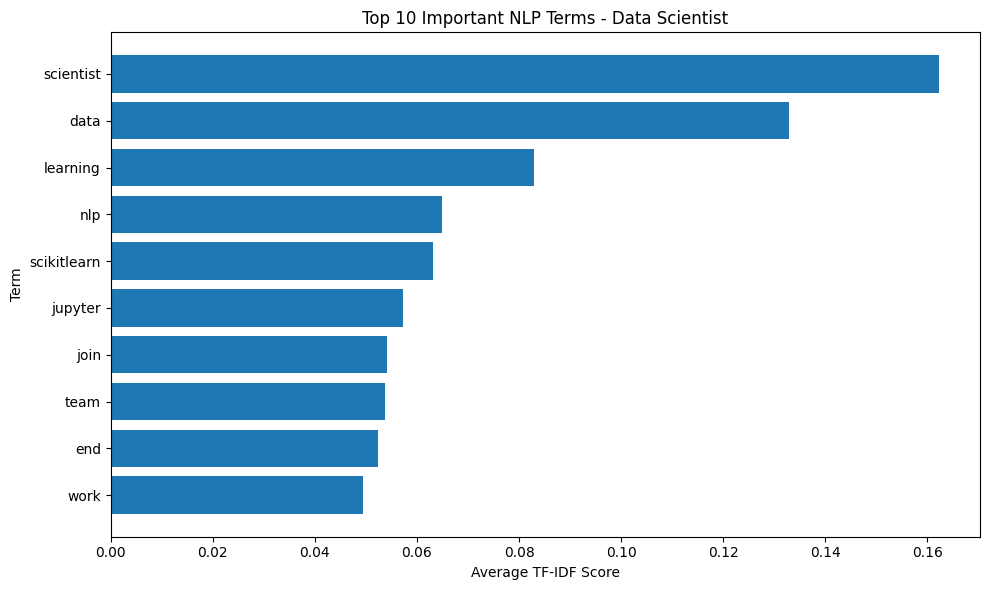

In [200]:
import matplotlib.pyplot as plt

# Select one career to visualize
selected_career = 'Data Scientist'

career_terms = top_tfidf_terms[
    top_tfidf_terms['Career'] == selected_career
].sort_values('TFIDF_Score', ascending=True)

plt.figure(figsize=(10, 6))

plt.barh(
    career_terms['Term'],
    career_terms['TFIDF_Score']
)

plt.xlabel('Average TF-IDF Score')
plt.ylabel('Term')
plt.title(f'Top 10 Important NLP Terms - {selected_career}')

plt.tight_layout()
plt.show()

### 20. Comparison of Important NLP Terms Across Careers

In [201]:
# Create a pivot table of top TF-IDF terms
tfidf_comparison = top_tfidf_terms.pivot_table(
    index='Term',
    columns='Career',
    values='TFIDF_Score',
    fill_value=0
)

# Select the 15 terms with the highest overall TF-IDF scores
top_terms_overall = (
    tfidf_comparison.mean(axis=1)
    .sort_values(ascending=False)
    .head(15)
    .index
)

tfidf_comparison_top = tfidf_comparison.loc[top_terms_overall]

tfidf_comparison_top

Career,Backend Engineer,Data Analyst,Data Engineer,Data Scientist,DevOps Engineer,ML Engineer,Product Manager,Research Scientist,Software Engineer,UX Designer
Term,,,,,,,,,,
engineer,0.1046,0.0000,0.1063,0.0000,0.1031,0.1037,0.0000,0.0000,0.1041,0.0000
data,0.0000,0.1304,0.1337,0.1329,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
scientist,0.0000,0.0000,0.0000,0.1622,0.0000,0.0000,0.0000,0.1594,0.0000,0.0000
end,0.0551,0.0000,0.0574,0.0523,0.0000,0.0587,0.0000,0.0000,0.0613,0.0000
product,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.2173,0.0000,0.0000,0.0000
backend,0.2051,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
devops,0.0000,0.0000,0.0000,0.0000,0.2027,0.0000,0.0000,0.0000,0.0000,0.0000
analyst,0.0000,0.1989,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
software,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.1978,0.0000


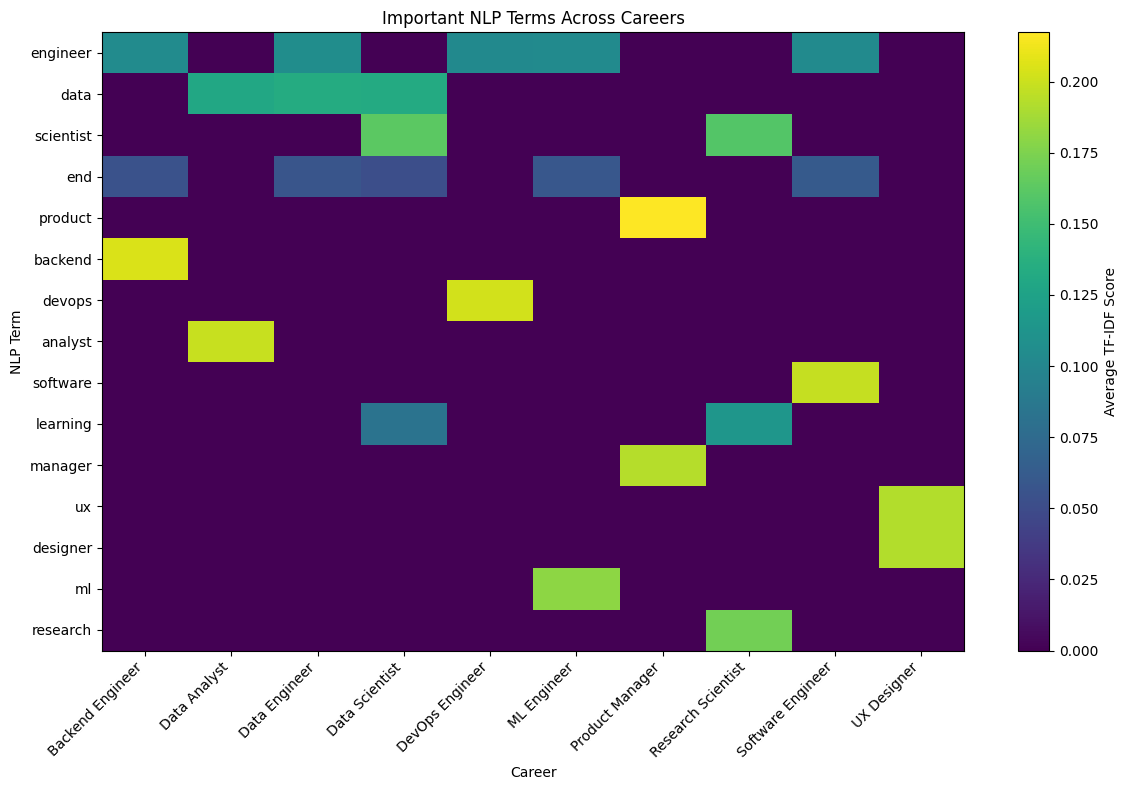

In [202]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

plt.imshow(
    tfidf_comparison_top,
    aspect='auto'
)

plt.xticks(
    range(len(tfidf_comparison_top.columns)),
    tfidf_comparison_top.columns,
    rotation=45,
    ha='right'
)

plt.yticks(
    range(len(tfidf_comparison_top.index)),
    tfidf_comparison_top.index
)

plt.xlabel('Career')
plt.ylabel('NLP Term')
plt.title('Important NLP Terms Across Careers')

plt.colorbar(label='Average TF-IDF Score')

plt.tight_layout()
plt.show()

### 21. Save NLP Analysis Results

In [203]:
# Save TF-IDF career-term results
top_tfidf_terms.to_csv(
    "../data/top_tfidf_terms_by_career.csv",
    index=False
)

print("NLP analysis results saved successfully.")
print("File: top_tfidf_terms_by_career.csv")

NLP analysis results saved successfully.
File: top_tfidf_terms_by_career.csv


### 22. Career Skill Profiles for Recommendation

In [204]:
# Display the career-skill demand matrix

career_skill_matrix.head(10)

Skill,A/B Testing,AWS,AWS SageMaker,Adobe XD,Agile,Airflow,Ansible,Azure,BigQuery,C++,...,Tableau,TensorFlow,Terraform,TypeScript,Usability Testing,User Research,Wireframing,dbt,gRPC,scikit-learn
title,,,,,,,,,,,,,,,,,,,,,
Backend Engineer,0.00,48.53,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,49.76,0.00
Data Analyst,59.01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,58.55,0.00,0.00,0.00,0.00,0.00,0.00,58.16,0.00,0.00
Data Engineer,0.00,45.32,0.00,0.00,0.00,44.85,0.00,42.85,44.79,0.00,...,0.00,0.00,42.71,0.00,0.00,0.00,0.00,44.32,0.00,0.00
Data Scientist,43.26,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,39.89,42.05,0.00,0.00,0.00,0.00,0.00,0.00,0.00,44.27
DevOps Engineer,0.00,47.59,0.00,0.00,0.00,0.00,46.07,42.98,0.00,0.00,...,0.00,0.00,44.01,0.00,0.00,0.00,0.00,0.00,0.00,0.00
ML Engineer,0.00,0.00,50.59,0.00,0.00,48.35,0.00,0.00,0.00,0.00,...,0.00,50.07,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Product Manager,58.75,0.00,0.00,0.00,59.01,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,59.08,0.00,0.00,0.00,0.00
Research Scientist,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,65.42,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Software Engineer,0.00,38.21,0.00,0.00,0.00,0.00,0.00,0.00,0.00,37.76,...,0.00,0.00,0.00,39.24,0.00,0.00,0.00,0.00,0.00,0.00


### 23. Career Skill Vectors for Recommendation

In [205]:
# Convert skill demand percentages to a 0-1 scale

career_skill_vectors = career_skill_matrix / 100

print("Career skill vector shape:", career_skill_vectors.shape)
print("\nExample career skill vector:")
display(career_skill_vectors.loc[['Data Scientist']])

Career skill vector shape: (10, 69)

Example career skill vector:


Skill,A/B Testing,AWS,AWS SageMaker,Adobe XD,Agile,Airflow,Ansible,Azure,BigQuery,C++,...,Tableau,TensorFlow,Terraform,TypeScript,Usability Testing,User Research,Wireframing,dbt,gRPC,scikit-learn
title,,,,,,,,,,,,,,,,,,,,,
Data Scientist,0.4326,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.3989,0.4205,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.4427


### 24. Create User Skill Profile

In [206]:
# Define a sample user's skills

user_skills = [
    'Python',
    'SQL',
    'Statistics',
    'Machine Learning',
    'Pandas'
]

print("User skills:")
for skill in user_skills:
    print("-", skill)

User skills:
- Python
- SQL
- Statistics
- Machine Learning
- Pandas


### 25. Convert User Skills into Feature Vector

In [207]:
# Create a user skill vector with the same 69 skill features
user_skill_vector = pd.Series(
    0,
    index=career_skill_vectors.columns,
    dtype=float
)

# Mark the user's skills as 1
for skill in user_skills:
    if skill in user_skill_vector.index:
        user_skill_vector[skill] = 1

print("Number of matched skills:",
      int((user_skill_vector > 0).sum()))

print("\nUser skill vector:")
display(user_skill_vector[user_skill_vector > 0])

Number of matched skills: 4

User skill vector:


Skill
Machine Learning    1.0
Python              1.0
SQL                 1.0
Statistics          1.0
dtype: float64

In [208]:
# Check which user skills are available in the dataset skill vocabulary

for skill in user_skills:
    print(f"{skill}: {skill in career_skill_vectors.columns}")

Python: True
SQL: True
Statistics: True
Machine Learning: True
Pandas: False


In [ ]:
#Pandas — not available in the dataset

### 26. Match User Skills with Job Market Skills

In [209]:
# Separate matched and unmatched user skills

matched_skills = [
    skill for skill in user_skills
    if skill in career_skill_vectors.columns
]

unmatched_skills = [
    skill for skill in user_skills
    if skill not in career_skill_vectors.columns
]

# Create the 69-feature user vector
user_skill_vector = pd.Series(
    0,
    index=career_skill_vectors.columns,
    dtype=float
)

# Set matched skills to 1
for skill in matched_skills:
    user_skill_vector[skill] = 1

print("Matched skills:", matched_skills)
print("Unmatched skills:", unmatched_skills)
print("Number of matched skills:", len(matched_skills))
print("Number of unmatched skills:", len(unmatched_skills))

Matched skills: ['Python', 'SQL', 'Statistics', 'Machine Learning']
Unmatched skills: ['Pandas']
Number of matched skills: 4
Number of unmatched skills: 1


### 27. Calculate Career Similarity

In [210]:
from sklearn.metrics.pairwise import cosine_similarity

# Calculate similarity between the user profile and each career
similarity_scores = cosine_similarity(
    user_skill_vector.values.reshape(1, -1),
    career_skill_vectors.values
)[0]

# Create recommendation results
career_recommendations = pd.DataFrame({
    'Career': career_skill_vectors.index,
    'Similarity_Score': similarity_scores
})

# Convert similarity to percentage
career_recommendations['Match_Percentage'] = (
    career_recommendations['Similarity_Score'] * 100
).round(2)

# Rank careers from highest to lowest match
career_recommendations = career_recommendations.sort_values(
    'Similarity_Score',
    ascending=False
).reset_index(drop=True)

career_recommendations

,Career,Similarity_Score,Match_Percentage
0,Data Scientist,0.537453,53.75
1,Research Scientist,0.498268,49.83
2,Data Analyst,0.473024,47.30
3,Backend Engineer,0.293975,29.40
4,Data Engineer,0.277587,27.76
5,Software Engineer,0.264383,26.44
6,Product Manager,0.155173,15.52
7,ML Engineer,0.144331,14.43
8,DevOps Engineer,0.139099,13.91
9,UX Designer,0.000000,0.00


### 28. Save Career Recommendation Results

In [211]:
# Save career recommendation results

career_recommendations.to_csv(
    "../data/career_recommendations_sample.csv",
    index=False
)

print("Career recommendation results saved successfully.")

Career recommendation results saved successfully.


### 29. Skill Gap Analysis

In [212]:
# Select the recommended career
selected_career = 'Data Scientist'

# Get the skill-demand profile for the selected career
career_profile = career_skill_vectors.loc[selected_career]

# Keep only skills demanded by the career
career_required_skills = career_profile[
    career_profile > 0
].sort_values(ascending=False)

# Identify skills the user does not have
missing_skills = career_required_skills[
    ~career_required_skills.index.isin(matched_skills)
]

# Create skill-gap dataframe
skill_gap = pd.DataFrame({
    'Skill': missing_skills.index,
    'Career_Demand': missing_skills.values
})

skill_gap['Demand_Percentage'] = (
    skill_gap['Career_Demand'] * 100
).round(2)

skill_gap = skill_gap.sort_values(
    'Demand_Percentage',
    ascending=False
).reset_index(drop=True)

print("Selected career:", selected_career)
print("Number of missing skills:", len(skill_gap))

display(skill_gap.head(10))

Selected career: Data Scientist
Number of missing skills: 10


,Skill,Career_Demand,Demand_Percentage
0,scikit-learn,0.4427,44.27
1,NLP,0.4373,43.73
2,A/B Testing,0.4326,43.26
3,R,0.4286,42.86
4,Spark,0.4259,42.59
5,TensorFlow,0.4205,42.05
6,Deep Learning,0.4158,41.58
7,PyTorch,0.4070,40.70
8,Tableau,0.3989,39.89
9,Jupyter,0.3881,38.81


### 30. Save Skill Gap Analysis

In [ ]:
skill_gap.to_csv(
    "../data/skill_gap_analysis_sample.csv",
    index=False
)

print("Skill gap analysis saved successfully.")

Skill gap analysis saved successfully.


### 31. Visualization of Career Skill Gaps

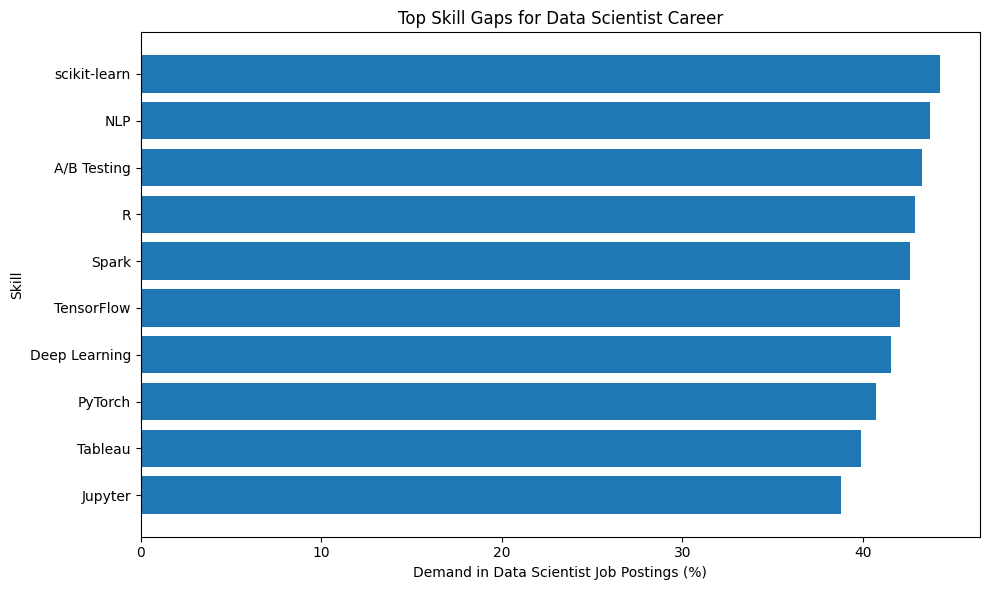

In [214]:
import matplotlib.pyplot as plt

# Select the top 10 missing skills
top_skill_gaps = skill_gap.head(10).sort_values(
    'Demand_Percentage',
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_skill_gaps['Skill'],
    top_skill_gaps['Demand_Percentage']
)

plt.xlabel('Demand in Data Scientist Job Postings (%)')
plt.ylabel('Skill')
plt.title('Top Skill Gaps for Data Scientist Career')

plt.tight_layout()
plt.show()

### 32. Create Reusable Skill Gap Function

In [215]:
def get_skill_gap(user_skills, career):
    # Match user's skills with the dataset vocabulary
    matched = [
        skill for skill in user_skills
        if skill in career_skill_vectors.columns
    ]

    # Skills not represented in the dataset
    unmatched = [
        skill for skill in user_skills
        if skill not in career_skill_vectors.columns
    ]

    # Get selected career's skill profile
    career_profile = career_skill_vectors.loc[career]

    # Skills demanded by the selected career
    required_skills = career_profile[
        career_profile > 0
    ].sort_values(ascending=False)

    # Identify missing skills
    missing = required_skills[
        ~required_skills.index.isin(matched)
    ]

    # Create result dataframe
    result = pd.DataFrame({
        'Skill': missing.index,
        'Demand_Percentage': (
            missing.values * 100
        ).round(2)
    })

    return result, matched, unmatched

In [216]:
data_scientist_gap, matched, unmatched = get_skill_gap(
    user_skills,
    'Data Scientist'
)

print("Matched skills:", matched)
print("Unmatched skills:", unmatched)

display(data_scientist_gap.head(10))

Matched skills: ['Python', 'SQL', 'Statistics', 'Machine Learning']
Unmatched skills: ['Pandas']


,Skill,Demand_Percentage
0,scikit-learn,44.27
1,NLP,43.73
2,A/B Testing,43.26
3,R,42.86
4,Spark,42.59
5,TensorFlow,42.05
6,Deep Learning,41.58
7,PyTorch,40.70
8,Tableau,39.89
9,Jupyter,38.81


### 33. Test Skill Gap Function for ML Engineer

In [217]:
ml_engineer_gap, matched, unmatched = get_skill_gap(
    user_skills,
    'ML Engineer'
)

print("Selected career: ML Engineer")
print("Matched skills:", matched)
print("Unmatched skills:", unmatched)

display(ml_engineer_gap.head(10))

Selected career: ML Engineer
Matched skills: ['Python', 'SQL', 'Statistics', 'Machine Learning']
Unmatched skills: ['Pandas']


,Skill,Demand_Percentage
0,AWS SageMaker,50.59
1,Spark,50.33
2,TensorFlow,50.07
3,Kubernetes,49.60
4,MLflow,49.21
5,CI/CD,48.68
6,Docker,48.41
7,PyTorch,48.41
8,Airflow,48.35
9,Feature Stores,48.22


### 34. Create Reusable Career Recommendation Function

In [218]:
def recommend_careers(user_skills, top_n=5):
    
    # Create a user vector using the same 69 skills
    user_vector = pd.Series(
        0,
        index=career_skill_vectors.columns,
        dtype=float
    )
    
    # Match user skills with dataset skills
    matched_skills = [
        skill for skill in user_skills
        if skill in career_skill_vectors.columns
    ]
    
    unmatched_skills = [
        skill for skill in user_skills
        if skill not in career_skill_vectors.columns
    ]
    
    # Set matched skills to 1
    for skill in matched_skills:
        user_vector[skill] = 1
    
    # Calculate cosine similarity
    similarity_scores = cosine_similarity(
        user_vector.values.reshape(1, -1),
        career_skill_vectors.values
    )[0]
    
    # Create recommendation dataframe
    recommendations = pd.DataFrame({
        'Career': career_skill_vectors.index,
        'Similarity_Score': similarity_scores
    })
    
    # Convert similarity to percentage
    recommendations['Match_Percentage'] = (
        recommendations['Similarity_Score'] * 100
    ).round(2)
    
    # Rank careers
    recommendations = recommendations.sort_values(
        'Similarity_Score',
        ascending=False
    ).reset_index(drop=True)
    
    return (
        recommendations.head(top_n),
        matched_skills,
        unmatched_skills
    )

In [219]:
recommendations, matched, unmatched = recommend_careers(
    user_skills,
    top_n=5
)

print("Matched skills:", matched)
print("Unmatched skills:", unmatched)

display(recommendations)

Matched skills: ['Python', 'SQL', 'Statistics', 'Machine Learning']
Unmatched skills: ['Pandas']


,Career,Similarity_Score,Match_Percentage
0,Data Scientist,0.537453,53.75
1,Research Scientist,0.498268,49.83
2,Data Analyst,0.473024,47.30
3,Backend Engineer,0.293975,29.40
4,Data Engineer,0.277587,27.76


### 35. Complete Career Recommendation Workflow

In [220]:
def career_recommendation_system(user_skills, top_n=5):
    
    # Get career recommendations
    recommendations, matched, unmatched = recommend_careers(
        user_skills,
        top_n=top_n
    )
    
    # Select the highest-ranked career
    best_career = recommendations.iloc[0]['Career']
    
    # Calculate skill gap for the best career
    skill_gap, _, _ = get_skill_gap(
        user_skills,
        best_career
    )
    
    return {
        'recommendations': recommendations,
        'matched_skills': matched,
        'unmatched_skills': unmatched,
        'recommended_career': best_career,
        'skill_gap': skill_gap
    }

In [221]:
result = career_recommendation_system(
    user_skills,
    top_n=5
)

print("Recommended Career:", result['recommended_career'])

print("\nMatched Skills:")
print(result['matched_skills'])

print("\nUnmatched Skills:")
print(result['unmatched_skills'])

print("\nCareer Recommendations:")
display(result['recommendations'])

print("\nTop Skill Gaps:")
display(result['skill_gap'].head(10))

Recommended Career: Data Scientist

Matched Skills:
['Python', 'SQL', 'Statistics', 'Machine Learning']

Unmatched Skills:
['Pandas']

Career Recommendations:


,Career,Similarity_Score,Match_Percentage
0,Data Scientist,0.537453,53.75
1,Research Scientist,0.498268,49.83
2,Data Analyst,0.473024,47.30
3,Backend Engineer,0.293975,29.40
4,Data Engineer,0.277587,27.76



Top Skill Gaps:


,Skill,Demand_Percentage
0,scikit-learn,44.27
1,NLP,43.73
2,A/B Testing,43.26
3,R,42.86
4,Spark,42.59
5,TensorFlow,42.05
6,Deep Learning,41.58
7,PyTorch,40.70
8,Tableau,39.89
9,Jupyter,38.81


### 36. Train-Test Split for Recommendation Evaluation

In [222]:
from sklearn.model_selection import train_test_split

# Split job postings into training and testing sets
train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df['title']
)

print("Training set shape:", train_df.shape)
print("Testing set shape:", test_df.shape)

print("\nTraining career distribution:")
print(train_df['title'].value_counts())

print("\nTesting career distribution:")
print(test_df['title'].value_counts())

Training set shape: (12000, 27)
Testing set shape: (3000, 27)

Training career distribution:
title
Software Engineer     1242
UX Designer           1240
Product Manager       1216
Data Analyst          1216
ML Engineer           1211
Data Engineer         1197
Data Scientist        1187
Backend Engineer      1170
DevOps Engineer       1162
Research Scientist    1159
Name: count, dtype: int64

Testing career distribution:
title
Software Engineer     310
UX Designer           310
Product Manager       304
Data Analyst          304
ML Engineer           303
Data Engineer         299
Data Scientist        297
Backend Engineer      293
DevOps Engineer       290
Research Scientist    290
Name: count, dtype: int64


### 37. Build Career Skill Profiles from Training Data

In [223]:
# Extract individual skills from training data only

train_career_skill_demand = (
    train_df[['title', 'required_skills']]
    .assign(Skill=train_df['required_skills'].str.split('|'))
    .explode('Skill')
)

train_career_skill_demand['Skill'] = (
    train_career_skill_demand['Skill'].str.strip()
)

# Count skill occurrences by career
train_career_skill_counts = (
    train_career_skill_demand
    .groupby(['title', 'Skill'])
    .size()
    .reset_index(name='Job_Postings')
)

# Count total job postings for each career
train_career_totals = (
    train_df['title']
    .value_counts()
    .rename('Total_Jobs')
    .reset_index()
)

train_career_totals.columns = ['title', 'Total_Jobs']

# Merge totals
train_career_skill_counts = train_career_skill_counts.merge(
    train_career_totals,
    on='title',
    how='left'
)

# Calculate skill demand percentage
train_career_skill_counts['Demand_Percentage'] = (
    train_career_skill_counts['Job_Postings']
    / train_career_skill_counts['Total_Jobs']
    * 100
).round(2)

print(
    "Training career-skill records:",
    len(train_career_skill_counts)
)

print(
    "Number of careers:",
    train_career_skill_counts['title'].nunique()
)

print(
    "Number of skills:",
    train_career_skill_counts['Skill'].nunique()
)

Training career-skill records: 117
Number of careers: 10
Number of skills: 69


### 38. Create Training Career-Skill Matrix

In [224]:
# Create career-skill demand matrix using training data only

train_career_skill_matrix = train_career_skill_counts.pivot_table(
    index='title',
    columns='Skill',
    values='Demand_Percentage',
    fill_value=0
)

# Convert percentages to 0-1 scale
train_career_skill_vectors = train_career_skill_matrix / 100

print(
    "Training career skill vector shape:",
    train_career_skill_vectors.shape
)

display(
    train_career_skill_vectors.loc[['Data Scientist']]
)

Training career skill vector shape: (10, 69)


Skill,A/B Testing,AWS,AWS SageMaker,Adobe XD,Agile,Airflow,Ansible,Azure,BigQuery,C++,...,Tableau,TensorFlow,Terraform,TypeScript,Usability Testing,User Research,Wireframing,dbt,gRPC,scikit-learn
title,,,,,,,,,,,,,,,,,,,,,
Data Scientist,0.4313,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.3934,0.4179,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.444


### 39. Prepare Test Profiles for Recommendation Evaluation

In [225]:
# Prepare test job skill profiles

test_profiles = test_df[
    ['job_id', 'title', 'required_skills']
].copy()

# Convert skill strings into lists
test_profiles['user_skills'] = (
    test_profiles['required_skills']
    .str.split('|')
    .apply(lambda skills: [skill.strip() for skill in skills])
)

print("Number of test profiles:", len(test_profiles))

print("\nExample test profile:")
print("Actual career:", test_profiles.iloc[0]['title'])
print("Skills:", test_profiles.iloc[0]['user_skills'])

Number of test profiles: 3000

Example test profile:
Actual career: Software Engineer
Skills: ['Git', 'Go', 'TypeScript', 'Docker']


### 40. Create Recommendation Evaluation Function

In [226]:
def predict_career_from_skills(user_skills):
    
    # Create a user vector using the training skill vocabulary
    user_vector = pd.Series(
        0,
        index=train_career_skill_vectors.columns,
        dtype=float
    )
    
    # Add skills that exist in the training vocabulary
    for skill in user_skills:
        if skill in user_vector.index:
            user_vector[skill] = 1
    
    # Calculate similarity with training career profiles
    similarity_scores = cosine_similarity(
        user_vector.values.reshape(1, -1),
        train_career_skill_vectors.values
    )[0]
    
    # Return the career with the highest similarity
    predicted_career = train_career_skill_vectors.index[
        similarity_scores.argmax()
    ]
    
    return predicted_career

In [228]:
# Test the prediction function on one unseen job

sample_skills = test_profiles.iloc[0]['user_skills']
actual_career = test_profiles.iloc[0]['title']

predicted_career = predict_career_from_skills(
    sample_skills
)

print("Skills:", sample_skills)
print("Actual career:", actual_career)
print("Predicted career:", predicted_career)

Skills: ['Git', 'Go', 'TypeScript', 'Docker']
Actual career: Software Engineer
Predicted career: Software Engineer


### 41. Generate Predictions for Test Set

In [229]:
# Generate career predictions for all test profiles

test_profiles['Predicted_Career'] = test_profiles[
    'user_skills'
].apply(predict_career_from_skills)

print("Predictions generated successfully.")

display(
    test_profiles[
        ['title', 'user_skills', 'Predicted_Career']
    ].head(10)
)

Predictions generated successfully.


,title,user_skills,Predicted_Career
809,Software Engineer,"[Git, Go, TypeScript, Docker]",Software Engineer
9882,Data Engineer,"[dbt, Azure, SQL, Airflow, Spark, BigQuery, Ka...",Data Engineer
9434,Data Engineer,"[dbt, AWS, Snowflake, Redshift, PostgreSQL, Sp...",Data Engineer
1252,DevOps Engineer,"[CI/CD, Docker, Ansible, AWS]",DevOps Engineer
13061,ML Engineer,"[AWS SageMaker, PyTorch, CI/CD, Spark, MLflow,...",ML Engineer
5672,Software Engineer,"[PostgreSQL, C++, AWS, Java, Redis, Docker, Go]",Software Engineer
3826,DevOps Engineer,"[Docker, Linux, Grafana, Kubernetes, Jenkins, ...",DevOps Engineer
13888,Backend Engineer,"[gRPC, SQL, Java, PostgreSQL, Docker, Kubernet...",Backend Engineer
14681,DevOps Engineer,"[Grafana, AWS, Python, Prometheus, Kubernetes]",DevOps Engineer
9472,DevOps Engineer,"[Kubernetes, Prometheus, Docker, GCP, AWS, Ter...",DevOps Engineer


### 42. Evaluate Career Recommendation Accuracy

In [230]:
from sklearn.metrics import accuracy_score, classification_report

# Actual and predicted careers
y_true = test_profiles['title']
y_pred = test_profiles['Predicted_Career']

# Calculate accuracy
accuracy = accuracy_score(y_true, y_pred)

print(f"Recommendation Accuracy: {accuracy:.4f}")
print(f"Recommendation Accuracy: {accuracy * 100:.2f}%")

print("\nClassification Report:")
print(
    classification_report(
        y_true,
        y_pred,
        zero_division=0
    )
)

Recommendation Accuracy: 0.9877
Recommendation Accuracy: 98.77%

Classification Report:
                    precision    recall  f1-score   support

  Backend Engineer       0.93      1.00      0.96       293
      Data Analyst       1.00      1.00      1.00       304
     Data Engineer       1.00      0.98      0.99       299
    Data Scientist       1.00      0.98      0.99       297
   DevOps Engineer       1.00      0.99      0.99       290
       ML Engineer       0.98      1.00      0.99       303
   Product Manager       1.00      1.00      1.00       304
Research Scientist       0.98      1.00      0.99       290
 Software Engineer       1.00      0.94      0.97       310
       UX Designer       1.00      1.00      1.00       310

          accuracy                           0.99      3000
         macro avg       0.99      0.99      0.99      3000
      weighted avg       0.99      0.99      0.99      3000



### 43. Confusion Matrix for Career Recommendation

<Figure size 1000x800 with 0 Axes>

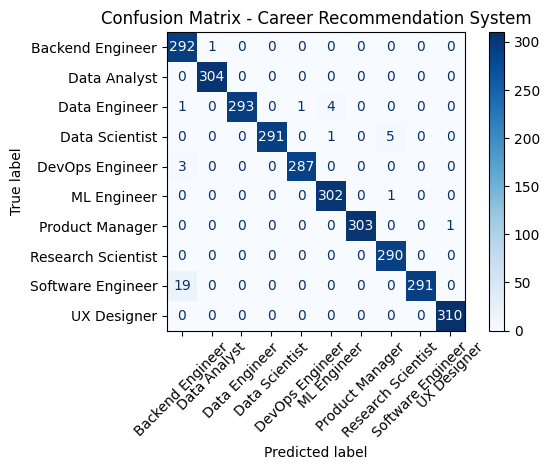

In [231]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate confusion matrix
cm = confusion_matrix(
    y_true,
    y_pred,
    labels=sorted(y_true.unique())
)

# Display confusion matrix
plt.figure(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=sorted(y_true.unique())
)

disp.plot(
    xticks_rotation=45,
    cmap='Blues'
)

plt.title('Confusion Matrix - Career Recommendation System')
plt.tight_layout()
plt.show()

### 44. Top-3 Career Recommendation Accuracy

In [232]:
def get_top_n_predictions(user_skills, n=3):
    
    # Create user vector
    user_vector = pd.Series(
        0,
        index=train_career_skill_vectors.columns,
        dtype=float
    )
    
    # Add matched skills
    for skill in user_skills:
        if skill in user_vector.index:
            user_vector[skill] = 1
    
    # Calculate similarity
    similarity_scores = cosine_similarity(
        user_vector.values.reshape(1, -1),
        train_career_skill_vectors.values
    )[0]
    
    # Rank careers
    ranked_indices = similarity_scores.argsort()[::-1]
    
    return train_career_skill_vectors.index[
        ranked_indices[:n]
    ].tolist()

In [233]:
sample_skills = test_profiles.iloc[0]['user_skills']
actual_career = test_profiles.iloc[0]['title']

top_3 = get_top_n_predictions(
    sample_skills,
    n=3
)

print("Actual career:", actual_career)
print("Top 3 recommendations:", top_3)
print("Correct career in Top 3:", actual_career in top_3)

Actual career: Software Engineer
Top 3 recommendations: ['Software Engineer', 'Backend Engineer', 'ML Engineer']
Correct career in Top 3: True


### 45. Evaluate Top-3 Recommendation Accuracy

In [234]:
# Generate Top-3 recommendations for all test profiles

test_profiles['Top_3_Careers'] = test_profiles[
    'user_skills'
].apply(
    lambda skills: get_top_n_predictions(skills, n=3)
)

# Check whether actual career appears in Top 3
test_profiles['Correct_in_Top_3'] = test_profiles.apply(
    lambda row: row['title'] in row['Top_3_Careers'],
    axis=1
)

# Calculate Top-3 accuracy
top_3_accuracy = test_profiles['Correct_in_Top_3'].mean()

print(f"Top-3 Recommendation Accuracy: {top_3_accuracy:.4f}")
print(f"Top-3 Recommendation Accuracy: {top_3_accuracy * 100:.2f}%")

Top-3 Recommendation Accuracy: 1.0000
Top-3 Recommendation Accuracy: 100.00%


In [235]:
display(
    test_profiles[
        ['title', 'user_skills', 'Top_3_Careers', 'Correct_in_Top_3']
    ].head(10)
)

,title,user_skills,Top_3_Careers,Correct_in_Top_3
809,Software Engineer,"[Git, Go, TypeScript, Docker]","[Software Engineer, Backend Engineer, ML Engin...",True
9882,Data Engineer,"[dbt, Azure, SQL, Airflow, Spark, BigQuery, Ka...","[Data Engineer, Data Analyst, Backend Engineer]",True
9434,Data Engineer,"[dbt, AWS, Snowflake, Redshift, PostgreSQL, Sp...","[Data Engineer, ML Engineer, Backend Engineer]",True
1252,DevOps Engineer,"[CI/CD, Docker, Ansible, AWS]","[DevOps Engineer, Backend Engineer, ML Engineer]",True
13061,ML Engineer,"[AWS SageMaker, PyTorch, CI/CD, Spark, MLflow,...","[ML Engineer, DevOps Engineer, Data Engineer]",True
5672,Software Engineer,"[PostgreSQL, C++, AWS, Java, Redis, Docker, Go]","[Software Engineer, Backend Engineer, DevOps E...",True
3826,DevOps Engineer,"[Docker, Linux, Grafana, Kubernetes, Jenkins, ...","[DevOps Engineer, Backend Engineer, Software E...",True
13888,Backend Engineer,"[gRPC, SQL, Java, PostgreSQL, Docker, Kubernet...","[Backend Engineer, Software Engineer, ML Engin...",True
14681,DevOps Engineer,"[Grafana, AWS, Python, Prometheus, Kubernetes]","[DevOps Engineer, Backend Engineer, Software E...",True
9472,DevOps Engineer,"[Kubernetes, Prometheus, Docker, GCP, AWS, Ter...","[DevOps Engineer, ML Engineer, Backend Engineer]",True


### 46. Career-wise Recommendation Performance

In [236]:
from sklearn.metrics import precision_recall_fscore_support

# Calculate precision, recall and F1-score for each career
precision, recall, f1, support = precision_recall_fscore_support(
    y_true,
    y_pred,
    labels=sorted(y_true.unique()),
    zero_division=0
)

career_performance = pd.DataFrame({
    'Career': sorted(y_true.unique()),
    'Precision': precision.round(3),
    'Recall': recall.round(3),
    'F1_Score': f1.round(3),
    'Support': support
})

career_performance

,Career,Precision,Recall,F1_Score,Support
0,Backend Engineer,0.927,0.997,0.961,293
1,Data Analyst,0.997,1.000,0.998,304
2,Data Engineer,1.000,0.980,0.990,299
3,Data Scientist,1.000,0.980,0.990,297
4,DevOps Engineer,0.997,0.990,0.993,290
5,ML Engineer,0.984,0.997,0.990,303
6,Product Manager,1.000,0.997,0.998,304
7,Research Scientist,0.980,1.000,0.990,290
8,Software Engineer,1.000,0.939,0.968,310
9,UX Designer,0.997,1.000,0.998,310


### 47. Visualization of Career-wise Performance

<Figure size 1200x600 with 0 Axes>

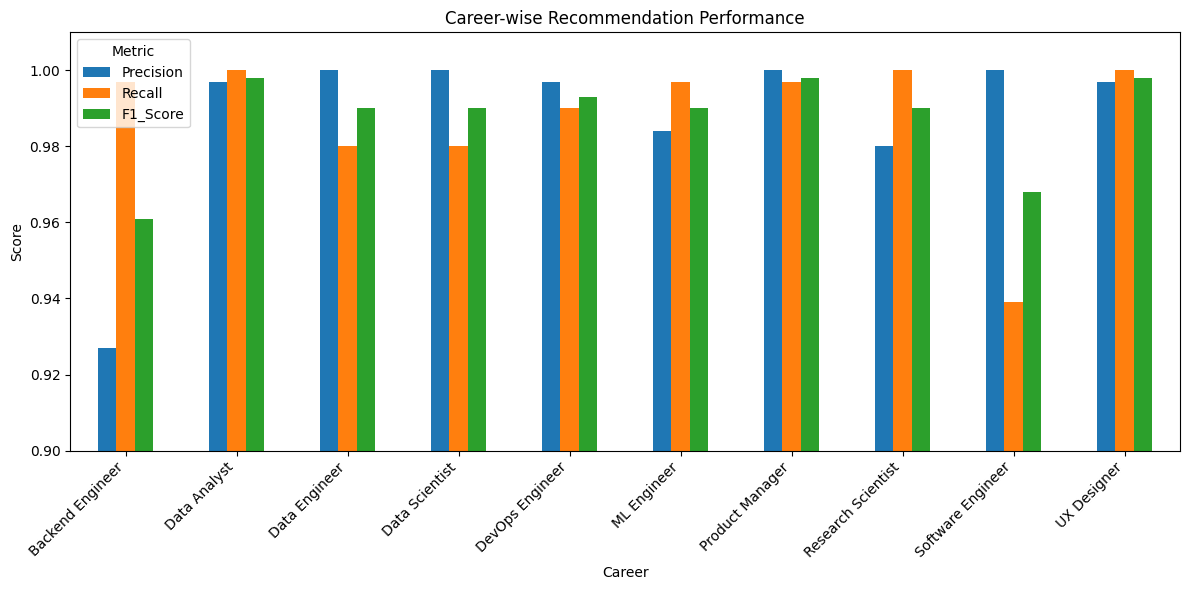

In [237]:
# Prepare data for visualization

performance_plot = career_performance.set_index('Career')[
    ['Precision', 'Recall', 'F1_Score']
]

plt.figure(figsize=(12, 6))

performance_plot.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.xlabel('Career')
plt.ylabel('Score')
plt.title('Career-wise Recommendation Performance')

plt.xticks(rotation=45, ha='right')
plt.ylim(0.90, 1.01)

plt.legend(title='Metric')

plt.tight_layout()
plt.show()

### 48. Error Analysis of Career Recommendations

In [238]:
# Identify incorrect predictions

incorrect_predictions = test_profiles[
    test_profiles['title'] != test_profiles['Predicted_Career']
].copy()

print(
    "Number of incorrect predictions:",
    len(incorrect_predictions)
)

print(
    "Error rate:",
    round(len(incorrect_predictions) / len(test_profiles) * 100, 2),
    "%"
)

display(
    incorrect_predictions[
        ['title', 'user_skills', 'Predicted_Career']
    ].head(20)
)

Number of incorrect predictions: 37
Error rate: 1.23 %


,title,user_skills,Predicted_Career
12199,ML Engineer,"[TensorFlow, PyTorch]",Research Scientist
2296,Data Engineer,"[Spark, Airflow]",ML Engineer
12090,Software Engineer,"[Python, Redis, Go]",Backend Engineer
6527,Data Scientist,"[Python, Statistics, Jupyter, Deep Learning, P...",Research Scientist
9742,Software Engineer,"[PostgreSQL, Python]",Backend Engineer
3877,Software Engineer,"[Python, Java, REST APIs]",Backend Engineer
3621,Software Engineer,"[Docker, SQL]",Backend Engineer
10742,Data Scientist,"[TensorFlow, PyTorch, Spark, Python]",ML Engineer
5435,DevOps Engineer,"[AWS, Kubernetes]",Backend Engineer
12435,Software Engineer,"[Java, SQL, Kubernetes]",Backend Engineer


### 49. Most Common Career Prediction Errors

In [239]:
# Count the most common actual vs predicted career pairs

error_pairs = (
    incorrect_predictions
    .groupby(['title', 'Predicted_Career'])
    .size()
    .reset_index(name='Error_Count')
    .sort_values('Error_Count', ascending=False)
    .reset_index(drop=True)
)

print("Most common incorrect career predictions:")

display(error_pairs)

Most common incorrect career predictions:


,title,Predicted_Career,Error_Count
0,Software Engineer,Backend Engineer,19
1,Data Scientist,Research Scientist,5
2,Data Engineer,ML Engineer,4
3,DevOps Engineer,Backend Engineer,3
4,Data Engineer,Backend Engineer,1
5,Backend Engineer,Data Analyst,1
6,Data Scientist,ML Engineer,1
7,Data Engineer,DevOps Engineer,1
8,ML Engineer,Research Scientist,1
9,Product Manager,UX Designer,1


### 50. Recommendation System Evaluation Summary

In [240]:
# Create final evaluation summary

macro_precision = career_performance['Precision'].mean()
macro_recall = career_performance['Recall'].mean()
macro_f1 = career_performance['F1_Score'].mean()

evaluation_summary = pd.DataFrame({
    'Metric': [
        'Top-1 Accuracy',
        'Top-3 Accuracy',
        'Macro Precision',
        'Macro Recall',
        'Macro F1-Score',
        'Test Profiles'
    ],
    'Value': [
        round(accuracy * 100, 2),
        round(top_3_accuracy * 100, 2),
        round(macro_precision * 100, 2),
        round(macro_recall * 100, 2),
        round(macro_f1 * 100, 2),
        len(test_profiles)
    ]
})

evaluation_summary

,Metric,Value
0,Top-1 Accuracy,98.77
1,Top-3 Accuracy,100.00
2,Macro Precision,98.82
3,Macro Recall,98.80
4,Macro F1-Score,98.76
5,Test Profiles,3000.00


### 51. Save Final Evaluation Results

In [241]:
# Save evaluation summary
evaluation_summary.to_csv(
    "../data/recommendation_evaluation_summary.csv",
    index=False
)

# Save career-wise performance
career_performance.to_csv(
    "../data/career_recommendation_performance.csv",
    index=False
)

# Save prediction errors
error_pairs.to_csv(
    "../data/recommendation_error_analysis.csv",
    index=False
)

print("Final evaluation results saved successfully.")

Final evaluation results saved successfully.


## 52. Key Findings and Conclusion

### Key Findings

1. The dataset contains 15,000 job postings covering 10 career categories and 69 unique skills.

2. Python and SQL were among the most frequently demanded skills across the analyzed job postings.

3. Career-wise skill analysis revealed distinctive skill profiles for different careers. For example, Data Scientist roles showed strong demand for scikit-learn, NLP, SQL, Machine Learning, Statistics, and related technologies.

4. Skill co-occurrence analysis identified frequently appearing skill combinations, including Python and SQL, Python and Statistics, and A/B Testing and SQL.

5. NLP preprocessing and TF-IDF analysis identified career-specific terms within job descriptions.

6. A content-based career recommendation approach was developed using cosine similarity between user skill vectors and career skill-demand vectors.

7. A reusable skill-gap analysis method was developed to identify missing skills according to the selected career's job-market demand.

8. The recommendation approach was evaluated using an 80% training and 20% testing split. The evaluation used 12,000 training postings and 3,000 unseen test profiles.

9. The recommendation system achieved a Top-1 accuracy of 98.77% and a Top-3 accuracy of 100.00% on the test set.

10. The main prediction errors occurred between careers with overlapping technical skill requirements, particularly Software Engineer and Backend Engineer.

### Conclusion

The analysis demonstrates that job-market skill requirements can be transformed into career-specific skill profiles and used to develop a personalized career recommendation and skill-gap analysis system. The results indicate that the proposed content-based approach can effectively match skill profiles with career categories within the analyzed dataset.